In [2]:
%load_ext autoreload
%autoreload 2
import sys
parent_dir = "C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal"

import json
import pandas as pd
import os
import pickle
sys.path.append(parent_dir)
holidays_path = "C:/Users/yuhang.hou/projects/holidays"
sys.path.append(holidays_path)
from backtester import *
from utils import *

cmd = 'W'
last_trading_days = get_last_trading_days(cmd)
ltds = {k:pd.to_datetime(v) for k,v in last_trading_days.items()}

business_days = load_business_days_cmd(cmd)
business_days = sorted(business_days)

def process_results(results):
    res =[]
    for date, data in results.items():
        temp= { }
        temp['date'] = date
        temp['level'] = data['level']
        temp['tc'] = data['tc']
        res.append(temp)
    res = pd.DataFrame(res)
    res = res.set_index('date')
    res['tc_cumsum'] = res['tc'].cumsum()
    return res

def load_future_data(data_path = f'./data/{cmd}',values = 'close'):
    files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
    dfs = []
    for file in files:
        dfs.append(pd.read_csv(os.path.join(data_path, file)).assign(
        contract=file.replace('.csv', ''),
        date=lambda df: pd.to_datetime(df['date'])
        ))
    

    big_df = pd.concat(dfs, ignore_index=True)
    pivot_df = big_df.pivot(index='date', columns='contract', values= values)

    return pivot_df

contract_df = load_future_data(f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/future/cme/{cmd}',['close'])
contract_df = contract_df.ffill()
# contract_df.head()
contract_df.dropna(how='all', inplace=True)
start_date = '2001-01-08'
end_date = '2025-09-20'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
# roll_schedules = [
#     'KKNNQUZZZZF*H*',
#     'KNNQUZZZZF*H*K*',
#     'NNQUZZZZF*H*K*K*',
#     'NQUZZZZF*H*K*K*N*',
#     'QUZZZZF*H*K*K*N*N*',
#     'UZZZZF*H*K*K*N*N*Q*',
#     'ZZZZF*H*K*K*N*N*Q*U*',
# ] # for SM BO

roll_schedules = [
    'HKKNNUUZZZH*H*',
    'KKNNUUZZZH*H*H*',
    'KNNUUZZZH*H*H*K*',
    'NNUUZZZH*H*H*K*K*',
    'NUUZZZH*H*H*K*K*N*',
    'UUZZZH*H*H*K*K*N*N*',
    'UZZZH*H*H*K*K*N*N*U*',
] # for W


# roll_schedules = [
#     'HKKNNXXXXF*F*H*',
#     'KKNNXXXXF*F*H*H*',
#     'KNNXXXXF*F*H*H*K*',
#     'NNXXXXF*F*H*H*K*K*',
#     'NXXXXF*F*H*H*K*K*N*',
#     'XXXXF*F*H*H*K*K*N*N*',
#     'XXXF*F*H*H*K*K*N*N*X*',
#     'XXF*F*H*H*K*K*N*N*X*X*',
#     'XF*F*H*H*K*K*N*N*X*X*X*',
#     'F*F*H*H*K*K*N*N*X*X*X*X*',
# ] #for S

# roll_schedules = [
#  'HKKNNUUZZZH*H*',
#     'KKNNUUZZZH*H*H*',
#     'KNNUUZZZH*H*H*K*',
#     'NNUUZZZH*H*H*K*K*',
#     'NUUZZZH*H*H*K*K*N*',
#     'UUZZZH*H*H*K*K*N*N*',
#     'UZZZH*H*H*K*K*N*N*U*',
# ] # for C

In [37]:
import numpy as np
df_plot = pd.DataFrame()
for i, roll_schedule in enumerate(roll_schedules):
    config = {
        'start_date': start_date,
        'end_date': end_date,
        'roll_start': -15,
        'roll_schedule':roll_schedule,
        'roll_dates': 1,
        'max_position': 1,
        'longshort': 1,
        'roll_style': 'monthly',  
        'cost_type':'percentage',
        'slippage': 0,
        'commission': 0,
        'roll_out' : 1,
        'vol_target': 5000,
        'round': 0,
        'max_daily_volume': 1,
        'vol_series':f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/{cmd}/{cmd}_0_3.csv',
        'symbol': cmd

    }

    backtest = VOlROllingBacktest(
        data = contract_df,
        config = config,
        trading_days=business_days,
        last_trading_day=ltds
    )
    

    results = backtest.run_backtest()
    res = process_results(results)
    df_plot[f'level_{i}'] = res['level']
    # break
    # with open(f'strategy/config/{cmd}_m_{i}.json', 'w', encoding='utf-8') as f:
    #     json.dump(config, f)
    # with open(f'strategy/backtest/{cmd}_m_{i}.pkl', 'wb') as f:
    #     pickle.dump(results, f)

In [38]:
import numpy as np
# df_plot = pd.DataFrame()
for i, roll_schedule in enumerate(roll_schedules):
    config = {
        'start_date': start_date,
        'end_date': end_date,
        'roll_start': -5,
        'roll_schedule':roll_schedule,
        'roll_dates': 1,
        'max_position': 1,
        'longshort': 1,
        'roll_style': 'monthly',  
        'cost_type':'percentage',
        'slippage': 0,
        'commission': 0,
        'roll_out' : 1,
        'vol_target': 5000,
        'round': 0,
        'max_daily_volume': 1,
        'vol_series':f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/{cmd}/{cmd}_0_3.csv',
        'symbol': cmd

    }

    backtest = VOlROllingBacktest(
        data = contract_df,
        config = config,
        trading_days=business_days,
        last_trading_day=ltds
    )
    

    results = backtest.run_backtest()
    res = process_results(results)
    df_plot[f'level_late_{i}'] = res['level']
    # break
    # with open(f'strategy/config/{cmd}_m_{i}.json', 'w', encoding='utf-8') as f:
    #     json.dump(config, f)
    # with open(f'strategy/backtest/{cmd}_m_{i}.pkl', 'wb') as f:
    #     pickle.dump(results, f)

<Axes: xlabel='date'>

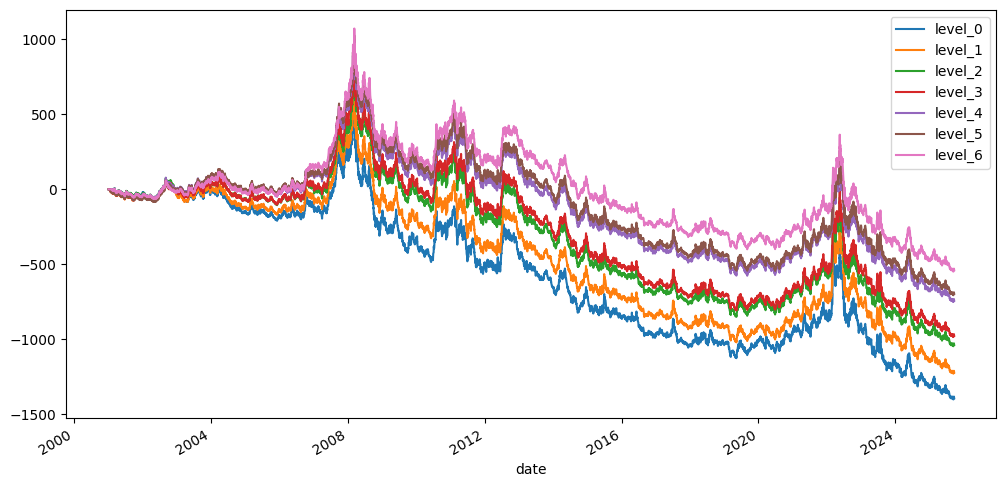

In [42]:
for i in range(len(roll_schedules)):
    df_plot[f'early_roll_{i}'] = df_plot[f'level_late_{i}'] - df_plot[f'level_{i}']
df_plot[[f'level_{i}' for i in range(len(roll_schedules))]].plot(figsize=(12,6))

In [40]:
import numpy as np
df_plot1 = pd.DataFrame()
for i, roll_schedule in enumerate(roll_schedules):
    config = {
        'start_date': start_date,
        'end_date': end_date,
        'roll_start': -15,
        'roll_schedule':roll_schedule,
        'roll_dates': 1,
        'max_position': 1,
        'longshort': 1,
        'roll_style': 'monthly',  
        'cost_type':'percentage',
        'slippage': 0,
        'commission': 0,
        'roll_out' : 1,
        'vol_target': 5000000,
        'round': 1,
        'max_daily_volume': 1,
        'vol_series':f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/{cmd}/{cmd}_0_3.csv',
        'symbol': cmd

    }

    backtest = VOlROllingBacktest(
        data = contract_df,
        config = config,
        trading_days=business_days,
        last_trading_day=ltds
    )
    

    results = backtest.run_backtest()
    res = process_results(results)
    df_plot1[f'level_{i}'] = res['level']
    # break
    # with open(f'strategy/config/{cmd}_m_{i}.json', 'w', encoding='utf-8') as f:
    #     json.dump(config, f)
    # with open(f'strategy/backtest/{cmd}_m_{i}.pkl', 'wb') as f:
    #     pickle.dump(results, f)

<Axes: xlabel='date'>

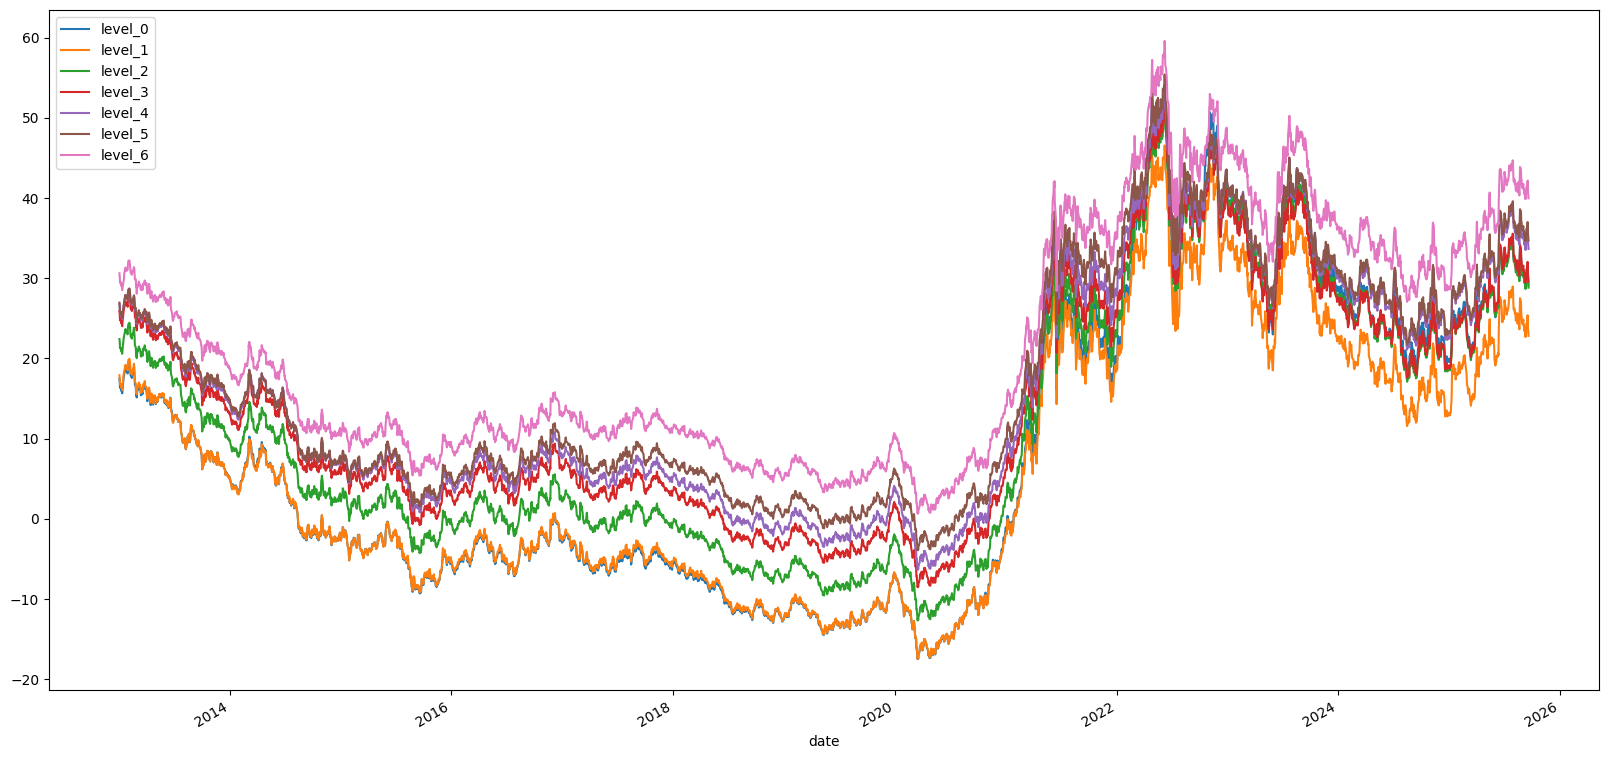

In [7]:
df_plot1.loc['2013-01-01':].plot(figsize=(20,10))

<Axes: xlabel='date'>

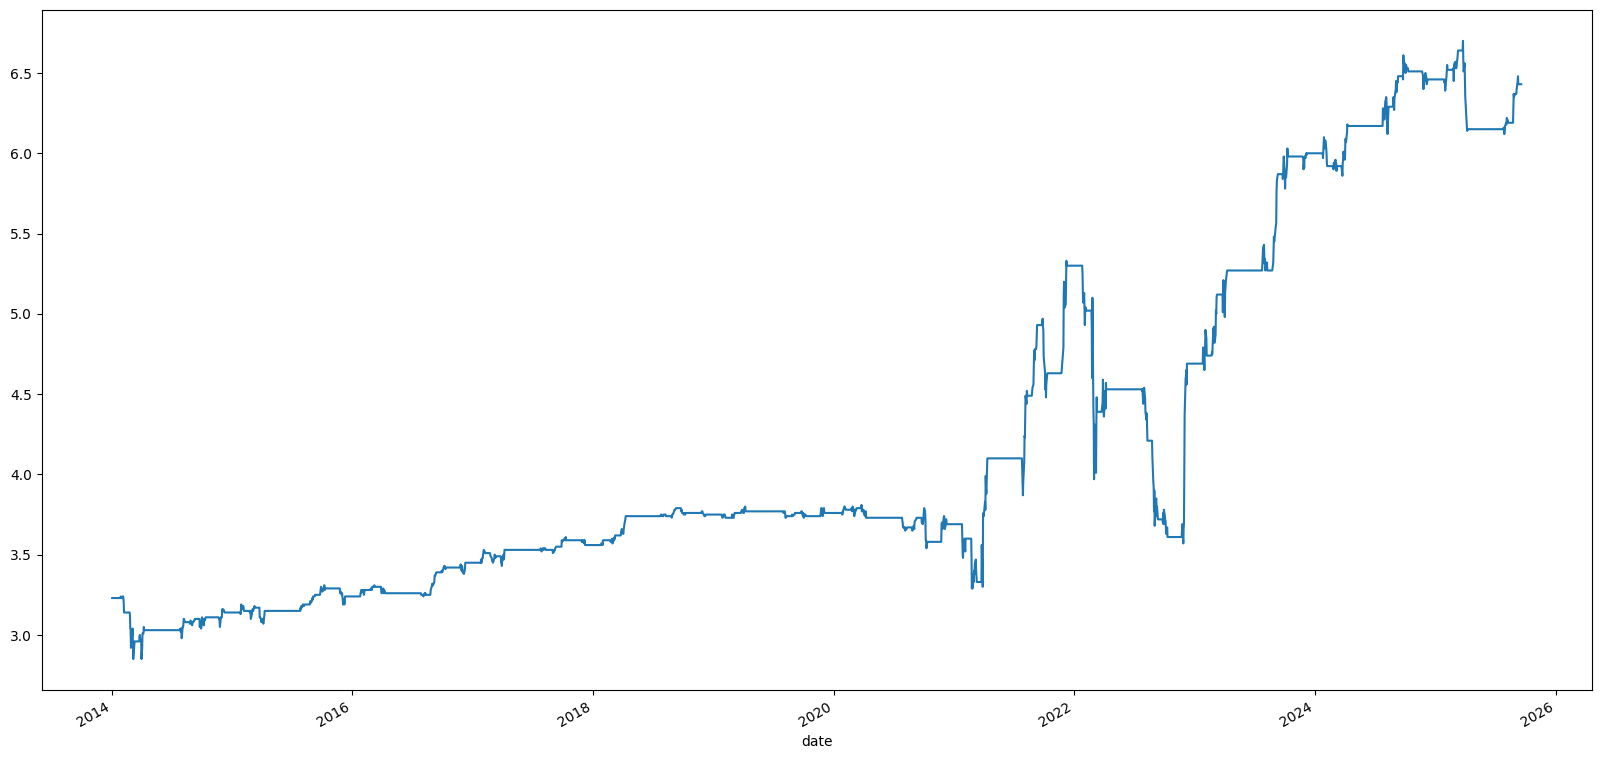

In [23]:
(df_plot['level_4'] - df_plot1['level_3']).loc['2014-01-01':].plot(figsize=(20,10))